## 1. What this notebook computes

Theorem **T3** of the Revision record pairs every self-consistent Kohn-Sham state of
the universe with the bare mass $+m$, the coupling $\lambda$ and the tip angle
$\theta$ with a state of the universe with the bare mass $-m$, the **same** coupling
$+\lambda$ and the tip angle $\pi - \theta$, with equal levels, energies and
energy-momentum profiles and the opposite scalar density. This notebook does the
proof by hand, with exact algebra where possible and with small, transparent
numerical computations where a number is needed. It

- reads the author's eight real $16 \times 16$ gamma matrices, draws them, checks
  that they are real and obey the anticommutation rule, and builds their product,
  the chirality $\Gamma$;
- shows that $\Gamma$ maps each $2 \times 2$ block of the Kohn-Sham problem onto its
  partner block as the Pauli matrix $\sigma_2$: this is the map of T3;
- re-derives every algebraic step of the proof of T3 exactly with sympy;
- computes the exact spectra at zero momentum of three universes: A (mass $+m$, tip
  angle $0$), its T3 partner B (mass $-m$, tip angle $\pi$) and the control C (mass
  $-m$, tip angle $0$, the tip NOT transformed), and finds the level that only C has
  inside the mass gap;
- solves the lowest band at small momenta by shooting and compares its slope with
  formulas derived here.

It needs Python only and takes about a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 19b (Theorem T3 by hand: the block map, the exact spectra and the control) is
the file `Revision/textbook/notebooks/19b_t3_by_hand.ipynb` of the repository
Dirac_claude. It reads the eight real 16 x 16 gamma matrices of the record, checks that
they are real signed permutation matrices that obey the anticommutation rule of the
signature (4,4), builds their product, the chirality Gamma, and shows that Gamma maps
each 2 x 2 Kohn-Sham block onto its partner block as the Pauli matrix sigma2. It then
re-derives with exact algebra (sympy) every step of the proof of theorem T3: the block
Hamiltonian, the boundary conditions, the densities and the mean field. It computes the
exact zero-momentum spectra of the universe of mass +M, of its T3 partner and of the
negative control with the untransformed tip, finds the level that only the control has
inside the mass gap, and solves the brane band at small momenta by shooting, comparing
its slope with the closed forms. It reproduces the corresponding Revision records and
draws six figures. Python only; no Rust is needed. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 19b_t3_by_hand.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 50 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 19b_t3_by_hand.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
19b_t3_by_hand.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/19b.captions.json`
- `Revision/textbook/figures/19b_1_eight_gammas.png`
- `Revision/textbook/figures/19b_2_gamma_block_map.png`
- `Revision/textbook/figures/19b_3_mean_field_map.png`
- `Revision/textbook/figures/19b_4_characteristic_functions.png`
- `Revision/textbook/figures/19b_5_k0_ladders.png`
- `Revision/textbook/figures/19b_6_brane_band.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 19 CHECKS PASSED (notebook 19b)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/19b_t3_by_hand.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 19b_t3_by_hand.ipynb
      python -m nbconvert --execute --inplace 19b_t3_by_hand.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- A sympy cell runs for more than a minute: the exact simplifications take a few seconds
  on a normal computer. If a cell runs much longer, check that the installed sympy is the
  version pinned in the requirements file, and run the notebook again.
- A shooting cell shows the label with the star for half a minute: this is normal: the
  shooting cells integrate the equations for thousands of levels at once (3000
  Runge-Kutta steps each). Wait until the label shows a number.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 19b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 19b (Theorem T3 by hand: the block map, the exact spectra and the control) is
# the file Revision/textbook/notebooks/19b_t3_by_hand.ipynb of the repository
# Dirac_claude. It reads the eight real 16 x 16 gamma matrices of the record, checks that
# they are real signed permutation matrices that obey the anticommutation rule of the
# signature (4,4), builds their product, the chirality Gamma, and shows that Gamma maps
# each 2 x 2 Kohn-Sham block onto its partner block as the Pauli matrix sigma2. It then
# re-derives with exact algebra (sympy) every step of the proof of theorem T3: the block
# Hamiltonian, the boundary conditions, the densities and the mean field. It computes the
# exact zero-momentum spectra of the universe of mass +M, of its T3 partner and of the
# negative control with the untransformed tip, finds the level that only the control has
# inside the mass gap, and solves the brane band at small momenta by shooting, comparing
# its slope with the closed forms. It reproduces the corresponding Revision records and
# draws six figures. Python only; no Rust is needed. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 19b_t3_by_hand.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 50
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 19b_t3_by_hand.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 19b_t3_by_hand.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/19b.captions.json
# - Revision/textbook/figures/19b_1_eight_gammas.png
# - Revision/textbook/figures/19b_2_gamma_block_map.png
# - Revision/textbook/figures/19b_3_mean_field_map.png
# - Revision/textbook/figures/19b_4_characteristic_functions.png
# - Revision/textbook/figures/19b_5_k0_ladders.png
# - Revision/textbook/figures/19b_6_brane_band.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 19 CHECKS PASSED (notebook 19b)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/19b_t3_by_hand.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 19b_t3_by_hand.ipynb
#     python -m nbconvert --execute --inplace 19b_t3_by_hand.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - A sympy cell runs for more than a minute: the exact simplifications take a few
#   seconds on a normal computer. If a cell runs much longer, check that the installed
#   sympy is the version pinned in the requirements file, and run the notebook again.
# - A shooting cell shows the label with the star for half a minute: this is normal: the
#   shooting cells integrate the equations for thousands of levels at once (3000
#   Runge-Kutta steps each). Wait until the label shows a number.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "19b"  # this notebook: chapter 19, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 19b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** (the author's names): $x_1, x_2, x_3$ = ordinary 3-space, which
  inflates; $x_4$ = the time; $x_5, x_6, x_7$ = the three **extra times**, which
  **deflate exponentially**; $x_8$ = the hidden space direction.
- **Hidden coordinate** $y$: it runs from the **tip** $y = -L$ ($L = 3$) to the
  **brane** $y = 0$.
- **Matrix**: a square table of numbers; **heat map**: a picture of a matrix in which
  every entry is a coloured square. **Real** matrix: all entries are real numbers.
  **Signed permutation matrix**: every row and every column holds exactly one entry
  $\pm 1$, all others are $0$.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: the author's eight real
  $16 \times 16$ matrices with $\gamma^a\gamma^b + \gamma^b\gamma^a =
  2\eta^{ab}\mathbf{1}$, where $\eta = \mathrm{diag}(+1, +1, +1, -1, -1, -1, -1, +1)$
  in the order $x_1, \dots, x_8$ and $\mathbf{1}$ is the unit matrix.
  **Chirality** $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$.
- **Pauli matrices** $\sigma_1 = \begin{pmatrix}0&1\\1&0\end{pmatrix}$,
  $\sigma_2 = \begin{pmatrix}0&-i\\i&0\end{pmatrix}$,
  $\sigma_3 = \begin{pmatrix}1&0\\0&-1\end{pmatrix}$. Each squares to $\mathbf{1}$,
  and any two of them anticommute ($\sigma_a\sigma_b = -\sigma_b\sigma_a$ for
  $a \ne b$).
- **Block**: one of the eight pairs of components into which the 16 components of
  the Kohn-Sham problem split; labelled $(j, s_2, s_3)$ with signs $\pm 1$.
- **Orbital** $\chi(y) = (\chi_1(y), \chi_2(y))$: a two-component wave function of
  one block; **level** $\varepsilon$: its energy.
- **Brane parity**: even means $\chi_2(0) = 0$, odd means $\chi_1(0) = 0$. **Tip
  angle** $\theta$: the boundary condition $(1 - Q(\theta))\chi(-L) = 0$ with
  $Q(\theta) = \cos\theta\,\sigma_3 + \sin\theta\,\sigma_2$.
- **Characteristic function**: a function of $\varepsilon$ whose zeros are exactly
  the levels.
- **Shooting**: integrate the equation from one end with the boundary condition
  there and adjust $\varepsilon$ until the condition at the other end holds.
- **Mass gap**: the energies $-m < \varepsilon < m$, where a free particle of mass
  $m$ has no level.
- **sympy**: a Python package that computes with exact symbols and fractions.
- Status labels: PROVED (exact), COMPUTED (numerical), ASSUMED (a choice),
  HYPOTHESIS, OPEN (not known).
- Units: $H = 1$ and $|m| = 1$.

## 4. The physical and mathematical situation

In the instantaneous Kohn-Sham model of the fermion field dirac16complex in the
author's deflating primordial field (record `Revision/kohn_sham/ks-theory.json`),
an orbital of block type $j = \pm 1$ with 3-momentum $k$ solves

$$h_j\chi = \varepsilon\chi,\qquad h_j = j\Big[-i\sigma_1\frac{d}{dy}
+ M_{eff}(y)\,\sigma_2 + \kappa(y)\,k\,\sigma_3\Big] + v_v(y)$$

on $-L \le y \le 0$, with $\kappa = e^{-Hy - a_{4,0}}$ (the redshift of the
3-momenta while 3-space inflates and the extra times deflate), the effective mass
$M_{eff} = m + \frac{15}{16}\lambda S$ and the potential $v_v = -\frac{1}{16}\lambda n$.
Move everything except the derivative to the right:
$-ij\sigma_1\,d\chi/dy = (\varepsilon - v_v)\chi - j(M_{eff}\sigma_2 +
\kappa k\sigma_3)\chi$. Multiply from the left by $ij\sigma_1$; on the left
$(ij\sigma_1)(-ij\sigma_1) = -i^2j^2\sigma_1^2 = \mathbf{1}$, on the right use
$j^2 = 1$, $\sigma_1\sigma_2 = i\sigma_3$ and $\sigma_1\sigma_3 = -i\sigma_2$:
$-ij^2(M_{eff}\,i\sigma_3 - \kappa k\,i\sigma_2) = M_{eff}\sigma_3 - \kappa k\sigma_2$.
The result is the first-order form of the record, $d\chi/dy = N\chi$ with
$N = M_{eff}\sigma_3 - \kappa k\sigma_2 + ij(\varepsilon - v_v)\sigma_1$. Writing
$\chi = (a, ib)$ with real $a$, $b$ it is real:

$$\frac{da}{dy} = M_{eff}\,a - (\kappa k + j(\varepsilon - v_v))\,b,\qquad
\frac{db}{dy} = (j(\varepsilon - v_v) - \kappa k)\,a - M_{eff}\,b .$$

The boundary conditions: at the brane the $Z_2$ mirror (ASSUMED), even or odd
parity, both solved; at the tip $(1 - Q(\theta))\chi(-L) = 0$ (chosen), which is
$\chi_2(-L) = 0$ for $\theta = 0$ and $\chi_1(-L) = 0$ for $\theta = \pi$.

**T3** (PROVED; records `t3-theory.json`, `wolfram-t3.json`, `python-t3.json`): the
map $(\chi, j) \to (\sigma_2\chi, -j)$ at the same momentum, with the brane parities
exchanged and $\theta \to \pi - \theta$, sends every self-consistent state with
$(m, \lambda, \theta)$ to one with $(-m, +\lambda, \pi - \theta)$, with equal levels,
occupations, energies and energy-momentum profiles; $S$ and $Q$ change sign. In the
real form, $\sigma_2(a, ib) = (b, ia)$: the map simply exchanges $a$ and $b$ and
reverses $j$.

**The three universes** of this notebook ($m = 1$, no interaction where spectra are
computed): A has the mass $+1$ and the tip angle $0$; B, its T3 partner, the mass
$-1$ and the tip angle $\pi$; C, the control, the mass $-1$ and the tip angle $0$.

**What is assumed and what is not shown.** The $Z_2$ brane is ASSUMED, the tip is a
chosen cutoff, the states are instantaneous mean-field states along a PRESCRIBED
BACKGROUND history. T3 maps solutions onto solutions; no creation process, rate or
amplitude of a pair of universes follows from it.

## 5. The eight real gamma matrices

The next cell imports the packages, reads the record `Revision/algebra/gammas.json`
and stores the eight matrices as arrays of **integers**, so that every product
below is computed exactly. A complex matrix would be stored in the record as a pair
(real part, imaginary part); a plain list of rows means a real matrix. The cell
checks that every entry is $-1$, $0$ or $+1$ and that every matrix is a signed
permutation matrix (exactly one nonzero entry in every row and every column).

In [2]:
import csv  # reads the tables (CSV files) of the record
import math  # sqrt, pi, exp, sinh, cosh, tanh of single numbers

import numpy as np  # arrays of numbers
import sympy as sp  # exact symbolic algebra
from matplotlib.colors import ListedColormap  # a colour map with three colours

GAMMAS = "Revision/algebra/gammas.json"  # the record of the gamma matrices
ALGEBRA = "Revision/algebra/reports/wolfram-algebra.json"  # its check report
fixture = json.loads(repository_file(GAMMAS).read_text(encoding="utf-8"))
stored_real = all(isinstance(g, list) for g in fixture["gamma"])  # no complex part
gamma = [np.array(g, dtype=int) for g in fixture["gamma"]]  # gamma[0] is x1
eta = [int(e) for e in fixture["eta"]]  # +1 +1 +1 -1 -1 -1 -1 +1
names = fixture["coordinates"]  # "x1", ..., "x8"
values = sorted({int(x) for g in gamma for x in g.flat})  # the values that occur
one_per_line = all(
    np.array_equal(np.abs(g).sum(axis=0), np.ones(16, dtype=int))
    and np.array_equal(np.abs(g).sum(axis=1), np.ones(16, dtype=int))
    for g in gamma)  # every column and every row holds one entry +1 or -1
say(f"{len(gamma)} matrices of size {gamma[0].shape}, entries {values}, "
    f"eta = {eta}")
check(stored_real and values == [-1, 0, 1] and one_per_line,
      "the eight gammas are real signed permutation matrices",
      record=f"{ALGEBRA}, checks reality and signed_permutation_matrices")

8 matrices of size (16, 16), entries [-1, 0, 1], eta = [1, 1, 1, -1, -1, -1, -1, 1]
PASS the eight gammas are real signed permutation matrices
     reproduces Revision/algebra/reports/wolfram-algebra.json, checks reality and
    signed_permutation_matrices


The next cell draws the eight matrices as heat maps: blue squares are $-1$, white
squares $0$, orange squares $+1$. The title of each picture names the coordinate and
its sign $\eta$ (space-like $+1$, time-like $-1$).

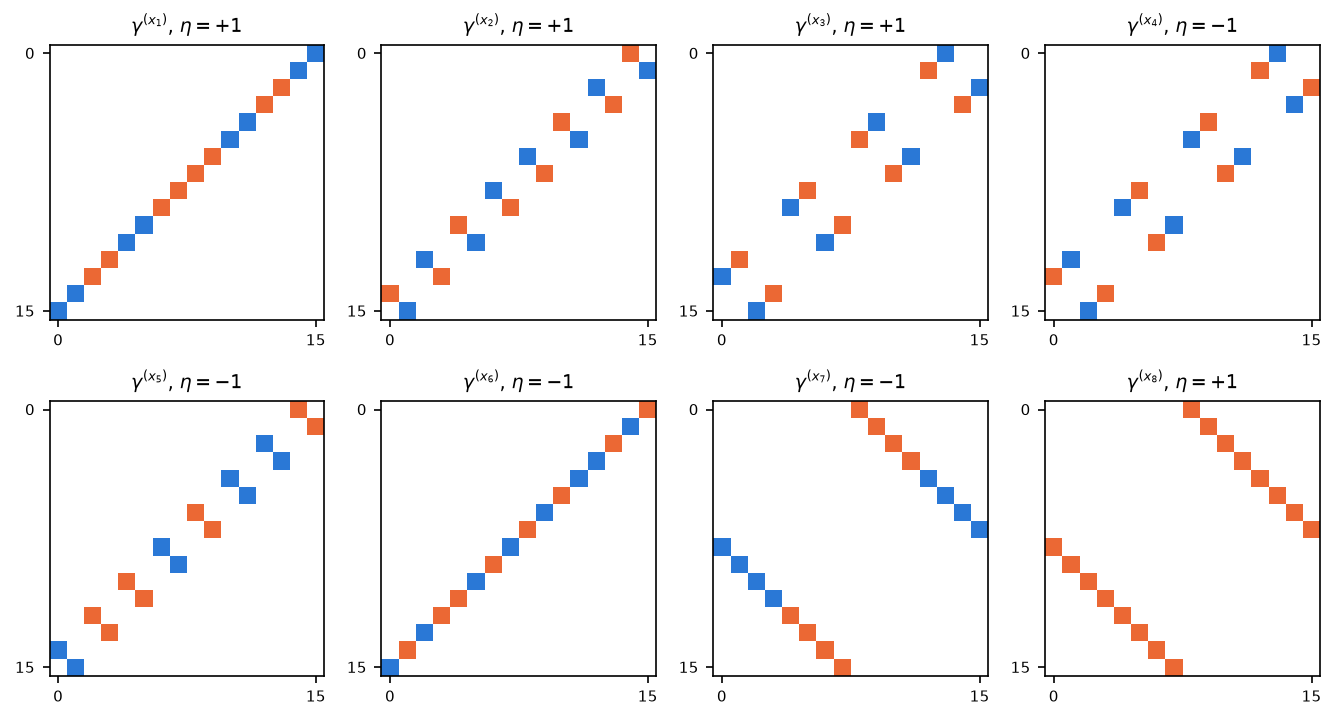

Figure 19b.1 saved as Revision/textbook/figures/19b_1_eight_gammas.png


In [3]:
THREE = ListedColormap(["#2a78d6", "#ffffff", "#eb6834"])  # -1, 0, +1
fig, axes = plt.subplots(2, 4, figsize=(9.0, 4.9))
for a, ax in enumerate(axes.flat):
    ax.imshow(gamma[a], cmap=THREE, vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title(f"$\\gamma^{{({names[a][0]}_{names[a][1]})}}$, "
                 f"$\\eta = {eta[a]:+d}$", fontsize=9)
    ax.set_xticks([0, 15])
    ax.set_yticks([0, 15])
    ax.tick_params(labelsize=7)
    ax.grid(False)
fig.tight_layout()
save_figure(fig, "eight_gammas",
            "The author's eight real $16 \\times 16$ gamma matrices "
            "$\\gamma^{(x_1)}, \\dots, \\gamma^{(x_8)}$ as heat maps (row index "
            "down, column index across, both from 0 to 15): blue is $-1$, white "
            "$0$, orange $+1$. Each matrix has exactly one nonzero entry in every "
            "row and every column. The four with $\\eta = +1$ (3-space and the "
            "hidden direction) are symmetric about the diagonal; the four with "
            "$\\eta = -1$ (the time and the three deflating extra times) are "
            "antisymmetric.")

The next cell checks the anticommutation rule
$\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\mathbf{1}$ for all $8 \times 8 = 64$
pairs, exactly in integers. It also checks the symmetry pattern seen in the
figure. Why must it hold? A signed permutation matrix $P$ satisfies $P^TP =
\mathbf{1}$ (the transpose $P^T$, rows and columns exchanged, is its inverse), and the
rule with $a = b$ says $\gamma^a\gamma^a = \eta^{aa}\mathbf{1}$, so $\gamma^a$ is its
own inverse up to the sign $\eta^{aa}$. Hence $(\gamma^a)^T = \eta^{aa}\gamma^a$:
symmetric for $\eta = +1$, antisymmetric for $\eta = -1$.

In [4]:
unit = np.eye(16, dtype=int)
worst = 0  # largest violation of the anticommutation rule (an integer)
for a in range(8):
    for b in range(8):
        anti = gamma[a] @ gamma[b] + gamma[b] @ gamma[a]
        rule = 2 * eta[a] * (a == b) * unit  # 2 eta^ab times the unit matrix
        worst = max(worst, int(np.max(np.abs(anti - rule))))
pattern = all(np.array_equal(g.T, e * g) for g, e in zip(gamma, eta))
say(f"largest violation of the anticommutation rule over 64 pairs: {worst}")
check(worst == 0 and pattern,
      "g^a g^b + g^b g^a = 2 eta^ab exactly; g^T = eta g (symmetry pattern)",
      record=f"{ALGEBRA}, checks Clifford_relation and symmetry_pattern")

largest violation of the anticommutation rule over 64 pairs: 0
PASS g^a g^b + g^b g^a = 2 eta^ab exactly; g^T = eta g (symmetry pattern)
     reproduces Revision/algebra/reports/wolfram-algebra.json, checks Clifford_relation
    and symmetry_pattern


## 6. The chirality and the map of T3

The next cell multiplies the eight matrices in the author's order,
$\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\cdots\gamma^{(x_7)}$, and checks:
$\Gamma$ is the diagonal matrix with $-1$ in the first eight places and $+1$ in the
last eight (the matrix stored in the record), $\Gamma^2 = \mathbf{1}$, and $\Gamma$
anticommutes with every gamma matrix. Then it reads the block basis $V$ of the
record `ks-theory.json`: 16 columns, two for each block $(j, s_2, s_3)$, written as
text (`0`, `1`, `-1`, `I`, `-I`, times $1/(2\sqrt2)$). It checks that $V$ is unitary
($V^\dagger V = \mathbf{1}$, where $V^\dagger$ is the transpose with every entry
complex-conjugated) and that $\Gamma$ sends the two columns of block
$(j, s_2, s_3)$ to the two columns of block $(-j, s_2, s_3)$ times $s_2\sigma_2$.

In [5]:
Gamma = gamma[7]  # gamma^(x8) first ...
for a in range(7):
    Gamma = Gamma @ gamma[a]  # ... times gamma^(x1), ..., gamma^(x7)
diagonal = np.diag([-1] * 8 + [1] * 8)
anticommutes = all(np.array_equal(Gamma @ g, -(g @ Gamma)) for g in gamma)
check(np.array_equal(Gamma, diagonal) and np.array_equal(Gamma @ Gamma, unit)
      and np.array_equal(Gamma, np.array(fixture["Gamma"])) and anticommutes,
      "Gamma = diag(-1 (8 times), +1 (8 times)), Gamma^2 = 1, Gamma g^a = -g^a Gamma",
      record=f"{ALGEBRA}, checks Gamma_diag and Gamma_anticommutes_with_gammas")

KS_THEORY = "Revision/kohn_sham/ks-theory.json"
ks = json.loads(repository_file(KS_THEORY).read_text(encoding="utf-8"))
ENTRY = {"0": 0.0, "1": 1.0, "-1": -1.0, "I": 1j, "-I": -1j}  # the record's text
V = np.array([[ENTRY[x] for x in row]
              for row in ks["blockBasis"]["unnormalisedColumns2Sqrt2V"]])
V = V / (2.0 * math.sqrt(2.0))  # the record stores 2 sqrt(2) V
labels = [tuple(int(x) for x in label) for label in ks["blockBasis"]["labels"]]
pauli1 = np.array([[0, 1], [1, 0]], dtype=complex)
pauli2 = np.array([[0, -1j], [1j, 0]])
pauli3 = np.array([[1, 0], [0, -1]], dtype=complex)
unitary = float(np.max(np.abs(V.conj().T @ V - np.eye(16))))
worst_map, worst_form = 0.0, 0.0
for b, (j, s2, s3) in enumerate(labels):
    p = labels.index((-j, s2, s3))  # the partner block
    Vb, Vp = V[:, 2 * b:2 * b + 2], V[:, 2 * p:2 * p + 2]
    worst_map = max(worst_map, float(np.max(np.abs(Gamma @ Vb
                                                    - Vp @ (s2 * pauli2)))))
    g8 = Vb.conj().T @ gamma[7] @ Vb  # gamma^(x8) inside block b
    g84 = Vb.conj().T @ gamma[7] @ gamma[3] @ Vb  # gamma^(x8) gamma^(x4) there
    worst_form = max(worst_form, float(np.max(np.abs(g8 - pauli3))),
                     float(np.max(np.abs(g84 - j * pauli1))))
say(f"largest deviations: unitarity {unitary:.1e}, block map {worst_map:.1e}, "
    f"forms gamma^(x8) = sigma3 and gamma^(x8) gamma^(x4) = j sigma1 "
    f"{worst_form:.1e}")
check(unitary < 1e-12 and worst_map < 1e-12 and worst_form < 1e-12,
      "Gamma maps block (j, s2, s3) onto block (-j, s2, s3) as s2 sigma2",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.Gamma_is_the_block_map")

PASS Gamma = diag(-1 (8 times), +1 (8 times)), Gamma^2 = 1, Gamma g^a = -g^a Gamma
     reproduces Revision/algebra/reports/wolfram-algebra.json, checks Gamma_diag and
    Gamma_anticommutes_with_gammas
largest deviations: unitarity 1.1e-16, block map 0.0e+00, forms gamma^(x8) = sigma3 and
    gamma^(x8) gamma^(x4) = j sigma1 1.1e-16
PASS Gamma maps block (j, s2, s3) onto block (-j, s2, s3) as s2 sigma2
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.Gamma_is_the_block_map


The next cell draws two matrices. Left: $\Gamma$ itself. Right: $\Gamma$ written in
the block basis, $V^\dagger\Gamma V$. Its entries are $0$ or $\pm i$ (the cell checks
that the real part vanishes), so the picture shows the imaginary part. The
$2 \times 2$ squares sit off the diagonal: block $b$ is joined to its partner block
with the opposite $j$, and each square is $\pm\sigma_2$.

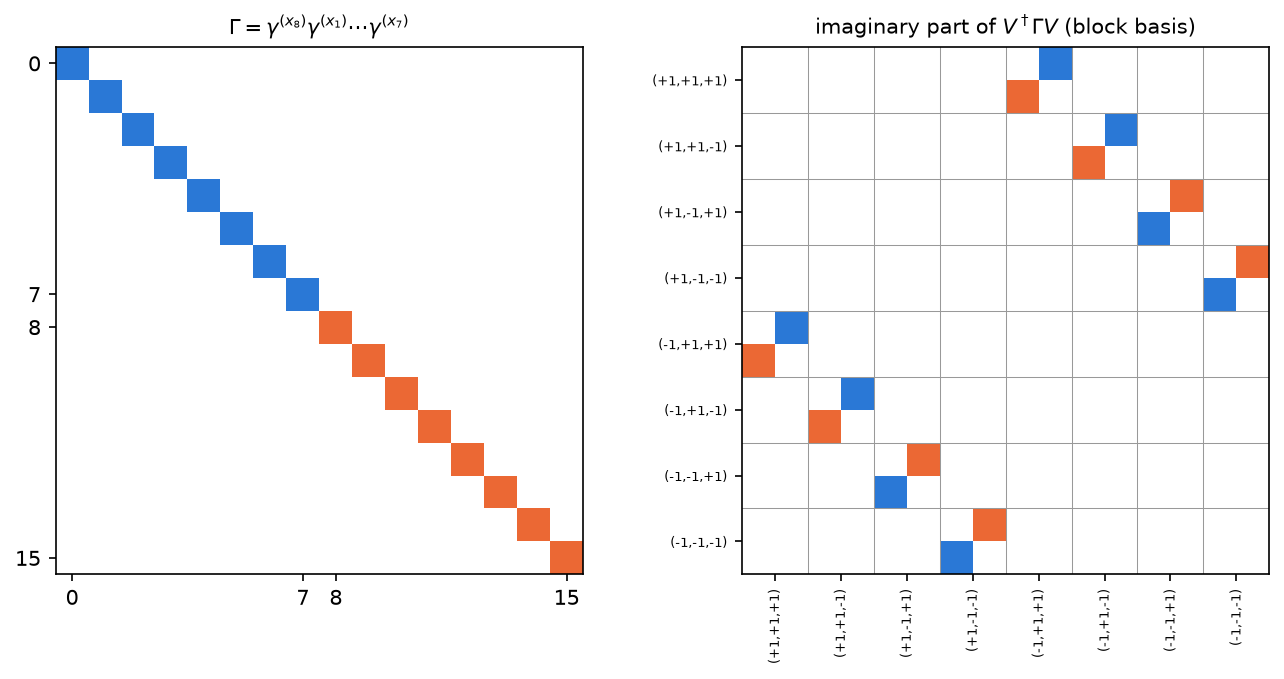

Figure 19b.2 saved as Revision/textbook/figures/19b_2_gamma_block_map.png
RESULT largest real part of V^dagger Gamma V = 2.2e-17


In [6]:
in_blocks = V.conj().T @ Gamma @ V  # Gamma in the block basis
real_part = float(np.max(np.abs(in_blocks.real)))
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 4.4))
left.imshow(Gamma, cmap=THREE, vmin=-1, vmax=1, interpolation="nearest")
left.set_title("$\\Gamma = \\gamma^{(x_8)}\\gamma^{(x_1)}\\cdots\\gamma^{(x_7)}$",
               fontsize=10)
right.imshow(in_blocks.imag, cmap=THREE, vmin=-1, vmax=1, interpolation="nearest")
right.set_title("imaginary part of $V^\\dagger\\Gamma V$ (block basis)", fontsize=10)
tags = [f"({j:+d},{s2:+d},{s3:+d})" for j, s2, s3 in labels]
right.set_xticks([2 * b + 0.5 for b in range(8)])
right.set_xticklabels(tags, rotation=90, fontsize=6)
right.set_yticks([2 * b + 0.5 for b in range(8)])
right.set_yticklabels(tags, fontsize=6)
for edge in range(1, 8):
    right.axhline(2 * edge - 0.5, color="0.6", lw=0.5)
    right.axvline(2 * edge - 0.5, color="0.6", lw=0.5)
for ax in (left, right):
    ax.grid(False)
left.set_xticks([0, 7, 8, 15])
left.set_yticks([0, 7, 8, 15])
fig.tight_layout()
save_figure(fig, "gamma_block_map",
            "Left: the chirality $\\Gamma$, the product of the eight real gamma "
            "matrices, as a heat map (blue $-1$, white $0$, orange $+1$; indices 0 "
            "to 15): $-1$ on the first eight diagonal places, $+1$ on the last "
            "eight. Right: the imaginary part of $\\Gamma$ in the Kohn-Sham block "
            "basis, with the block labels $(j, s_2, s_3)$ on the axes. The nonzero "
            "$2 \\times 2$ squares join each block to the block with the opposite "
            "$j$ and the same $s_2, s_3$, and each square is $\\pm\\sigma_2$: this "
            "is the map $(\\chi, j) \\to (\\sigma_2\\chi, -j)$ of theorem T3.")
report("largest real part of V^dagger Gamma V", f"{real_part:.1e}")

## 7. The proof of T3, step by step, in exact algebra

**Step 1: the block Hamiltonian.** Conjugating a Pauli matrix with $\sigma_2$ gives
$\sigma_2\sigma_1\sigma_2 = -\sigma_1$, $\sigma_2\sigma_2\sigma_2 = \sigma_2$,
$\sigma_2\sigma_3\sigma_2 = -\sigma_3$ (because $\sigma_2$ anticommutes with
$\sigma_1$ and $\sigma_3$ and $\sigma_2^2 = \mathbf{1}$). The constant matrix
$\sigma_2$ also passes through $d/dy$. So

$$\sigma_2 h_j(M)\sigma_2 = j\Big[+i\sigma_1\frac{d}{dy} + M\sigma_2 -
\kappa k\sigma_3\Big] + v_v = (-j)\Big[-i\sigma_1\frac{d}{dy} + (-M)\sigma_2 +
\kappa k\sigma_3\Big] + v_v = h_{-j}(-M).$$

If $h_j(M)\chi = \varepsilon\chi$, then $h_{-j}(-M)(\sigma_2\chi) =
\sigma_2h_j(M)\sigma_2\sigma_2\chi = \sigma_2h_j(M)\chi = \varepsilon\,\sigma_2\chi$:
the image is an orbital of the partner block with the mass $-M$ and the SAME level.
The next cell checks the three conjugation rules and the identity
$h_{-j}(-M)(\sigma_2\chi) = \sigma_2h_j(M)\chi$ for arbitrary functions $M(y)$,
$\kappa(y)$, $v_v(y)$, $\chi_1(y)$, $\chi_2(y)$ and both $j$, with sympy; as a
control it checks that without $M \to -M$ the identity fails. It also checks the
same statement for the first-order matrix: $\sigma_2N_j(M)\sigma_2 = N_{-j}(-M)$.

In [7]:
y = sp.Symbol("y", real=True)  # the hidden coordinate
k, eps, vv = sp.symbols("k epsilon v_v", real=True)  # momentum, level, potential
Mf, kappa, vf = (sp.Function(name)(y) for name in ("M", "kappa", "v"))
chi = sp.Matrix([sp.Function("chi1")(y), sp.Function("chi2")(y)])  # any orbital
s1 = sp.Matrix([[0, 1], [1, 0]])  # the Pauli matrices, exactly
s2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s3 = sp.Matrix([[1, 0], [0, -1]])
one = sp.eye(2)


def h(j, mass, c):
    """h_j(mass) applied to the two-component function c."""
    return j * (-sp.I * s1 * c.diff(y) + mass * s2 * c + kappa * k * s3 * c) + vf * c


def is_zero(matrix):
    """True when every entry simplifies to exactly 0."""
    return all(sp.simplify(sp.expand(entry)) == 0 for entry in matrix)


rules = (s2 * s1 * s2 == -s1 and s2 * s2 * s2 == s2 and s2 * s3 * s2 == -s3)
maps = all(is_zero(h(-j, -Mf, s2 * chi) - s2 * h(j, Mf, chi)) for j in (1, -1))
control = not is_zero(h(-1, Mf, s2 * chi) - s2 * h(1, Mf, chi))  # no M -> -M
Ms = sp.Symbol("M", real=True)
jj = sp.Symbol("j", real=True)


def N(j, mass):
    """The first-order matrix N of d chi/dy = N chi (constant data)."""
    return mass * s3 - sp.Symbol("kappa") * k * s2 + sp.I * j * (eps - vv) * s1


ode = (s2 * N(jj, Ms) * s2 - N(-jj, -Ms)).applyfunc(sp.expand) == sp.zeros(2, 2)
say(f"conjugation rules: {rules}; block map for both j: {maps}; control fails "
    f"as it must: {control}; first-order form: {ode}")
check(rules and maps and control,
      "sigma2 h_j(M) sigma2 = h_(-j)(-M) for arbitrary M(y), kappa(y), v(y)",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.block_hamiltonian_map")
check(ode, "sigma2 N_j(M) sigma2 = N_(-j)(-M) for the first-order form",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check T3.ode_map")

conjugation rules: True; block map for both j: True; control fails as it must: True;
    first-order form: True
PASS sigma2 h_j(M) sigma2 = h_(-j)(-M) for arbitrary M(y), kappa(y), v(y)
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.block_hamiltonian_map
PASS sigma2 N_j(M) sigma2 = N_(-j)(-M) for the first-order form
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check T3.ode_map


**Step 2: the boundary conditions.** At the tip, $\sigma_2Q(\theta)\sigma_2 =
\cos\theta\,\sigma_2\sigma_3\sigma_2 + \sin\theta\,\sigma_2 = -\cos\theta\,\sigma_3 +
\sin\theta\,\sigma_2 = Q(\pi - \theta)$, because $\cos(\pi - \theta) = -\cos\theta$
and $\sin(\pi - \theta) = \sin\theta$. Hence $(1 - Q(\theta))\chi = 0$ holds exactly
when $(1 - Q(\pi - \theta))\sigma_2\chi = \sigma_2(1 - Q(\theta))\chi = 0$: the image
obeys the tip condition with the angle $\pi - \theta$. At the brane, $\sigma_2(1 -
\sigma_3)\sigma_2 = 1 + \sigma_3$: the even condition $(1 - \sigma_3)\chi(0) = 0$
(that is $\chi_2(0) = 0$) becomes the odd one $(1 + \sigma_3)\sigma_2\chi(0) = 0$.
The next cell checks both, and as a control that the image $\sigma_2(1, 0)$ of the
solution $(1, 0)$ of the condition $\theta = 0$ violates the UNtransformed condition
and obeys the transformed one.

In [8]:
theta = sp.Symbol("theta", real=True)


def Q(angle):
    """The tip matrix Q(angle) = cos(angle) sigma3 + sin(angle) sigma2."""
    return sp.cos(angle) * s3 + sp.sin(angle) * s2


tip = (s2 * Q(theta) * s2 - Q(sp.pi - theta)).applyfunc(sp.simplify) == sp.zeros(2, 2)
e1 = sp.Matrix([1, 0])  # the vector (1, 0)
zero2 = sp.zeros(2, 1)
tip_control = ((one - Q(0)) * e1 == zero2 and (one - Q(0)) * (s2 * e1) != zero2
               and (one - Q(sp.pi)) * (s2 * e1) == zero2)
brane = s2 * (one - s3) * s2 == one + s3
say(f"tip: sigma2 Q(theta) sigma2 = Q(pi - theta): {tip}; control: {tip_control}; "
    f"brane parities exchanged: {brane}")
check(tip and tip_control and brane,
      "tip angle theta -> pi - theta and the brane parities are exchanged",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, checks "
             "T3.tip_condition_map and T3.brane_parities_exchanged")

tip: sigma2 Q(theta) sigma2 = Q(pi - theta): True; control: True; brane parities
    exchanged: True
PASS tip angle theta -> pi - theta and the brane parities are exchanged
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, checks
    T3.tip_condition_map and T3.brane_parities_exchanged


**Step 3: the densities.** Per orbital the record `ks-theory.json` uses (up to a
common positive factor) $n_o = \chi^\dagger\chi$, $s_o = j\chi^\dagger\sigma_2\chi$,
$t_o = j\chi^\dagger\sigma_3\chi$, $q_o = \chi^\dagger\sigma_3\chi$ and
$c_o = j\chi^\dagger\sigma_1\chi$, where $\chi^\dagger$ is the row of the complex
conjugates. Under $(\chi, j) \to (\sigma_2\chi, -j)$, with $\sigma_2^\dagger =
\sigma_2$: $n_o \to \chi^\dagger\sigma_2\sigma_2\chi = n_o$;
$s_o \to -j\chi^\dagger\sigma_2\sigma_2\sigma_2\chi = -s_o$;
$t_o \to -j\chi^\dagger\sigma_2\sigma_3\sigma_2\chi = +t_o$;
$q_o \to \chi^\dagger\sigma_2\sigma_3\sigma_2\chi = -q_o$;
$c_o \to -j\chi^\dagger\sigma_2\sigma_1\sigma_2\chi = +c_o$. The next cell checks the
signs $(+, -, +, -, +)$ for an arbitrary complex $\chi = (a_1 + ib_1, a_2 + ib_2)$ and
both $j$.

In [9]:
a1, b1, a2, b2 = sp.symbols("a1 b1 a2 b2", real=True)
psi = sp.Matrix([a1 + sp.I * b1, a2 + sp.I * b2])  # an arbitrary complex orbital


def densities(j, c):
    """(n, s, t, q, c) of one orbital c of block type j."""
    dag = c.H  # the row of complex conjugates
    return [sp.expand((dag * m * c)[0, 0]) for m in
            (one, j * s2, j * s3, s3, j * s1)]


SIGNS = (1, -1, 1, -1, 1)  # expected: n, t, c even; s, q odd
signs_ok = all(sp.expand(after - sign * before) == 0
               for j in (1, -1)
               for after, before, sign in zip(densities(-j, s2 * psi),
                                              densities(j, psi), SIGNS))
say(f"n = {densities(1, psi)[0]},  s (j = +1) = {densities(1, psi)[1]}")
check(signs_ok, "under the map n, t, c keep their sign, s and q change it",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.orbital_densities")

n = a1**2 + a2**2 + b1**2 + b2**2,  s (j = +1) = 2*a1*b2 - 2*a2*b1
PASS under the map n, t, c keep their sign, s and q change it
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.orbital_densities


**Step 4: the mean field.** The record gives $M_{eff} = m + c_M\lambda S$ and
$v_v = c_v\lambda n$ with $c_M = 15/16$ and $c_v = -1/16$, and the interaction energy
density $e_{int} = \frac{15}{32}\lambda S^2 - \frac{1}{32}\lambda n^2$. The image
state has the densities $(n, -S)$ (step 3). For it to be self-consistent in the
partner block, its effective mass must be $-M_{eff}$ (step 1) and its potential
$v_v$ unchanged. With the bare mass $-m$ and the SAME coupling,
$-m + c_M\lambda(-S) = -(m + c_M\lambda S) = -M_{eff}$, and $c_v\lambda n$ is
unchanged. With $(-m, -\lambda)$ instead, $-m + c_M(-\lambda)(-S) = -m +
c_M\lambda S \ne -M_{eff}$ whenever $\lambda S \ne 0$. The next cell reads the two
coefficients from the record and checks this, the evenness of $e_{int}$ in $S$, and
that $M_{eff} - m$ and $v_v$ are the derivatives of $e_{int}$ with respect to $S$
and $n$.

In [10]:
potentials = ks["exchange"]["kohnShamPotentials"]
cM = sp.Rational(potentials["Meff_coefficient_of_lambda_S"])  # 15/16
cv = sp.Rational(potentials["vv_coefficient_of_lambda_n"])  # -1/16
m, lam, S, n = sp.symbols("m lambda S n", real=True)


def M_eff(mass, coupling, scalar):
    """The effective mass m + cM lambda S of the record."""
    return mass + cM * coupling * scalar


e_int = sp.Rational(15, 32) * lam * S ** 2 - sp.Rational(1, 32) * lam * n ** 2
partner = sp.expand(M_eff(-m, lam, -S) + M_eff(m, lam, S)) == 0
wrong = sp.expand(M_eff(-m, -lam, -S) + M_eff(m, lam, S)) != 0
even = sp.expand(e_int.subs(S, -S) - e_int) == 0
derivatives = (sp.expand(sp.diff(e_int, S) - (M_eff(m, lam, S) - m)) == 0
               and sp.expand(sp.diff(e_int, n) - cv * lam * n) == 0)
say(f"cM = {cM}, cv = {cv}; (-m, +lambda) works: {partner}; (-m, -lambda) fails: "
    f"{wrong}; e_int even in S: {even}; derivatives: {derivatives}")
check(partner and wrong and even and derivatives and (cM, cv) == (
    sp.Rational(15, 16), sp.Rational(-1, 16)),
    "M_eff(-m, +lambda, -S) = -M_eff(m, lambda, S); (-m, -lambda) fails",
    record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
           "T3.mean_field_map")

cM = 15/16, cv = -1/16; (-m, +lambda) works: True; (-m, -lambda) fails: True; e_int even
    in S: True; derivatives: True
PASS M_eff(-m, +lambda, -S) = -M_eff(m, lambda, S); (-m, -lambda) fails
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.mean_field_map


The next cell draws step 4. For every value of the scalar density $S$ (horizontal
axis) it draws the mass that the image needs, $-M_{eff}(m, \lambda, S)$, the mass
that the partner universe $(-m, +\lambda)$ gives to the image density $-S$, and the
mass that the universe $(-m, -\lambda)$ would give. The coupling
$\lambda = 0.8$ is exaggerated on purpose so that the slopes can be seen; the
identity holds for every $\lambda$.

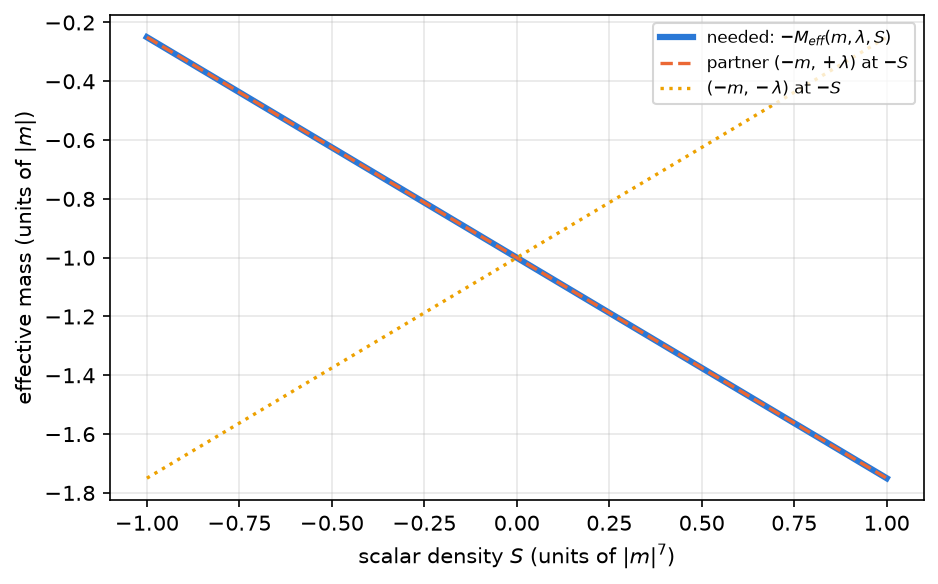

Figure 19b.3 saved as Revision/textbook/figures/19b_3_mean_field_map.png
PASS the drawn lines: the partner gives the needed mass, (-m, -lambda) does not


In [11]:
S_values = np.linspace(-1.0, 1.0, 201)
lam_demo, m_demo, cM_value = 0.8, 1.0, float(cM)
need = -(m_demo + cM_value * lam_demo * S_values)  # -M_eff(m, lambda, S)
give_partner = -m_demo + cM_value * lam_demo * (-S_values)  # (-m, +lambda) at -S
give_wrong = -m_demo + cM_value * (-lam_demo) * (-S_values)  # (-m, -lambda) at -S
fig, ax = plt.subplots()
ax.plot(S_values, need, color="#2a78d6", lw=3.0,
        label="needed: $-M_{eff}(m, \\lambda, S)$")
ax.plot(S_values, give_partner, color="#eb6834", lw=1.6, ls="--",
        label="partner $(-m, +\\lambda)$ at $-S$")
ax.plot(S_values, give_wrong, color="#eda100", lw=1.6, ls=":",
        label="$(-m, -\\lambda)$ at $-S$")
ax.set_xlabel("scalar density $S$ (units of $|m|^7$)")
ax.set_ylabel("effective mass (units of $|m|$)")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "mean_field_map",
            "Step 4 of the proof of T3: the effective mass that the image state "
            "needs, $-M_{eff}(m, \\lambda, S)$ (blue), against the scalar density "
            "$S$, with $m = 1$ and an exaggerated coupling $\\lambda = 0.8$ "
            "(units of $|m|$ and $|m|^7$). The partner universe with the bare mass "
            "$-m$ and the same coupling $+\\lambda$ gives exactly this mass to the "
            "image density $-S$ (orange dashed, on top of the blue line); the "
            "universe with $(-m, -\\lambda)$ gives a line with the opposite slope "
            "(yellow dotted), which agrees only at $S = 0$.")
check(float(np.max(np.abs(need - give_partner))) < 1e-15
      and float(np.max(np.abs(need - give_wrong))) > 1.0,
      "the drawn lines: the partner gives the needed mass, (-m, -lambda) does not")

## 8. The exact spectra at zero momentum

Take $k = 0$, no interaction ($M_{eff} = M$ constant, $v_v = 0$). Then
$N = M\sigma_3 + ij\varepsilon\sigma_1$ and $N^2 = M^2\sigma_3^2 +
(ij\varepsilon)^2\sigma_1^2 + Mij\varepsilon(\sigma_3\sigma_1 + \sigma_1\sigma_3) =
(M^2 - \varepsilon^2)\mathbf{1}$, because $\sigma_3^2 = \sigma_1^2 = \mathbf{1}$,
$(ij)^2 = -1$ and $\sigma_3\sigma_1 + \sigma_1\sigma_3 = 0$. Write
$p = \sqrt{M^2 - \varepsilon^2}$. In the series $e^{Ny} = \sum_n (Ny)^n/n!$ the even
powers give $p^{2r}y^{2r}\mathbf{1}$ and the odd ones $p^{2r}y^{2r+1}N$, so

$$\chi(y) = e^{Ny}\chi(0) = \Big[\cosh(py)\,\mathbf{1} +
\frac{\sinh(py)}{p}\,N\Big]\chi(0).$$

Start at the brane with the parity ($\chi(0) = (1, 0)$ for even, $(0, 1)$ for odd),
go to the tip $y = -L$ and ask the tip condition: the component that must vanish
there, as a function of $\varepsilon$, is the **characteristic function**, and its
zeros are the levels. For A ($M$, $j$, $\theta = 0$, the second component must
vanish) and B ($-M$, $-j$, $\theta = \pi$, the first component must vanish) and the
control C ($-M$, $j$, $\theta = 0$) the next cell computes all six functions with
sympy and checks: A even $= -$(B odd), A odd $=$ B even (so A and B have the SAME
levels, sector by sector after exchanging the parities); C even $=$ A even, but C
odd $\ne$ A odd (the control differs in the odd sector).

In [12]:
Mp, L = sp.symbols("M L", positive=True)
yy = sp.Symbol("yy", real=True)
p = sp.sqrt(Mp ** 2 - eps ** 2)


def propagator(j, mass):
    """exp(N yy) for k = 0, v = 0: cosh(p yy) 1 + sinh(p yy)/p N."""
    N0 = mass * s3 + sp.I * j * eps * s1
    return sp.cosh(p * yy) * one + sp.sinh(p * yy) / p * N0


e2 = sp.Matrix([0, 1])  # the vector (0, 1)
at_tip = {yy: -L}
D = {}  # characteristic functions, for j = +1
D["A even"] = (propagator(1, Mp) * e1)[1].subs(at_tip)  # chi2(-L)
D["A odd"] = (propagator(1, Mp) * e2)[1].subs(at_tip)
D["B even"] = (propagator(-1, -Mp) * e1)[0].subs(at_tip)  # chi1(-L)
D["B odd"] = (propagator(-1, -Mp) * e2)[0].subs(at_tip)
D["C even"] = (propagator(1, -Mp) * e1)[1].subs(at_tip)  # chi2(-L)
D["C odd"] = (propagator(1, -Mp) * e2)[1].subs(at_tip)
for name in D:
    say(f"D({name}) = {sp.simplify(D[name])}")
pairs_equal = (sp.simplify(D["A even"] + D["B odd"]) == 0
               and sp.simplify(D["A odd"] - D["B even"]) == 0)
control_differs = (sp.simplify(D["C even"] - D["A even"]) == 0
                   and sp.simplify(D["C odd"] - D["A odd"]) != 0)
check(pairs_equal and control_differs,
      "k = 0: A and B have equal characteristic functions; C differs (odd sector)",
      record="Revision/pairing/kohn_sham/reports/python-t3.json, check "
             "T3.exact_k0_spectra")

D(A even) = -I*epsilon*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2)
D(A odd) = M*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2) + cosh(L*sqrt(M**2 -
    epsilon**2))
D(B even) = M*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2) + cosh(L*sqrt(M**2
    - epsilon**2))
D(B odd) = I*epsilon*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2)
D(C even) = -I*epsilon*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2)
D(C odd) = -M*sinh(L*sqrt(M**2 - epsilon**2))/sqrt(M**2 - epsilon**2) + cosh(L*sqrt(M**2
    - epsilon**2))
PASS k = 0: A and B have equal characteristic functions; C differs (odd sector)
     reproduces Revision/pairing/kohn_sham/reports/python-t3.json, check
    T3.exact_k0_spectra


Dropping the constant factor $-ij$ of the even function, the three different
functions are, with $C = \cosh(pL)$ and $\Sigma = \sinh(pL)/p$:
A even $= \varepsilon\,\Sigma$, A odd $= C + M\Sigma$, C odd $= C - M\Sigma$. For
$\varepsilon^2 > M^2$, $p = ir$ with $r = \sqrt{\varepsilon^2 - M^2}$, and
$\cosh(irL) = \cos(rL)$, $\sinh(irL)/(ir) = \sin(rL)/r$: all three are real for real
$\varepsilon$. The next cell evaluates them for $M = 1$, $L = 3$ on a fine grid of
$\varepsilon$ between $0$ and $4$, finds every zero (a sign change between two grid
points, refined by bisection), and compares the levels of A with the analytic levels
of the record `Revision/kohn_sham/results/spectrum/free-k0-analytic.csv` (even:
$\varepsilon = 0$ and $\sqrt{M^2 + (n\pi/L)^2}$; odd: $\tan(rL) = -r/M$).

In [13]:
M_BARE, L_TIP = 1.0, 3.0  # the mass |m| and the tip distance L of the record


def C_and_Sigma(e):
    """cosh(pL) and sinh(pL)/p for the level(s) e, real for every real e."""
    pc = np.sqrt(M_BARE ** 2 - np.asarray(e, dtype=float) ** 2 + 0j)  # complex p
    small = np.abs(pc) < 1e-12  # p = 0: sinh(pL)/p -> L
    safe = np.where(small, 1.0, pc)
    sigma = np.where(small, L_TIP, np.sinh(safe * L_TIP) / safe)
    return np.cosh(pc * L_TIP).real, sigma.real


def f_A_even(e):
    return np.asarray(e) * C_and_Sigma(e)[1]


def f_A_odd(e):
    c, sig = C_and_Sigma(e)
    return c + M_BARE * sig


def f_C_odd(e):
    c, sig = C_and_Sigma(e)
    return c - M_BARE * sig


def zeros(f, top=4.0, points=40001):
    """All sign changes of f on (0, top], each refined by 80 bisection steps."""
    grid = np.linspace(1e-9, top, points)
    values = f(grid)
    found = []
    for i in np.nonzero(np.sign(values[:-1]) * np.sign(values[1:]) < 0)[0]:
        low, high = grid[i], grid[i + 1]
        for _ in range(80):
            middle = 0.5 * (low + high)
            if np.sign(f(middle)) == np.sign(f(low)):
                low = middle
            else:
                high = middle
        found.append(0.5 * (low + high))
    return found


levels = {"A even": [0.0] + zeros(f_A_even), "A odd": zeros(f_A_odd),
          "C odd": zeros(f_C_odd)}
for name, values in levels.items():
    say(f"{name}: " + ", ".join(f"{v:.10f}" for v in values))
SPECTRUM = "Revision/kohn_sham/results/spectrum/free-k0-analytic.csv"
with repository_file(SPECTRUM).open(encoding="utf-8", newline="") as handle:
    rows = [r for r in csv.DictReader(handle)
            if float(r["m"]) == 1.0 and float(r["L"]) == 3.0]
recorded = {parity: sorted(float(r["eps_analytic"]) for r in rows
                           if r["parity"] == parity
                           and 0.0 <= float(r["eps_analytic"]) < 4.0)
            for parity in ("even", "odd")}
worst = max(max(abs(x - y) for x, y in zip(levels["A even"], recorded["even"])),
            max(abs(x - y) for x, y in zip(levels["A odd"], recorded["odd"])))
report("largest difference of the levels of A from the record", f"{worst:.1e}")
check(len(levels["A even"]) == len(recorded["even"])
      and len(levels["A odd"]) == len(recorded["odd"]) and worst < 1e-12,
      "the k = 0 levels of A are the analytic levels of the record",
      record=f"{SPECTRUM}, rows m = 1, L = 3")

A even: 0.0000000000, 1.4479719304, 2.3208814802, 3.2969083095
A odd: 1.2922928281, 2.0106285600, 2.9119358754, 3.8829900326
C odd: 0.1008511214, 1.6875789860, 2.6839784554, 3.7115109122
RESULT largest difference of the levels of A from the record = 8.9e-16
PASS the k = 0 levels of A are the analytic levels of the record
     reproduces Revision/kohn_sham/results/spectrum/free-k0-analytic.csv, rows m = 1, L =
    3


The control's odd function $C - M\Sigma$ has a zero inside the mass gap
$0 < \varepsilon < M$, where A has none. There $p = q$ is real and the zero is
$\cosh(qL) = M\sinh(qL)/q$, that is $\tanh(qL) = q/M$; the level is
$\varepsilon_b = \sqrt{M^2 - q^2} = M/\cosh(qL)$ (because $q^2 = M^2\tanh^2(qL)$
and $1 - \tanh^2 = 1/\cosh^2$). For A the condition would be $\tanh(qL) = -q/M$,
impossible for $q > 0$. The next cell checks the two forms of $\varepsilon_b$, that
the control's odd levels above the gap are NOT those of A, and draws the three
functions (left: the even function, common to all three universes after the
exchange of parities; right: the odd functions of A and C).

RESULT sub-gap level of the control eps_b = 0.100851121375 |m|
PASS only the control has a level in the gap, eps_b = M/cosh(qL), tanh(qL) = q/M


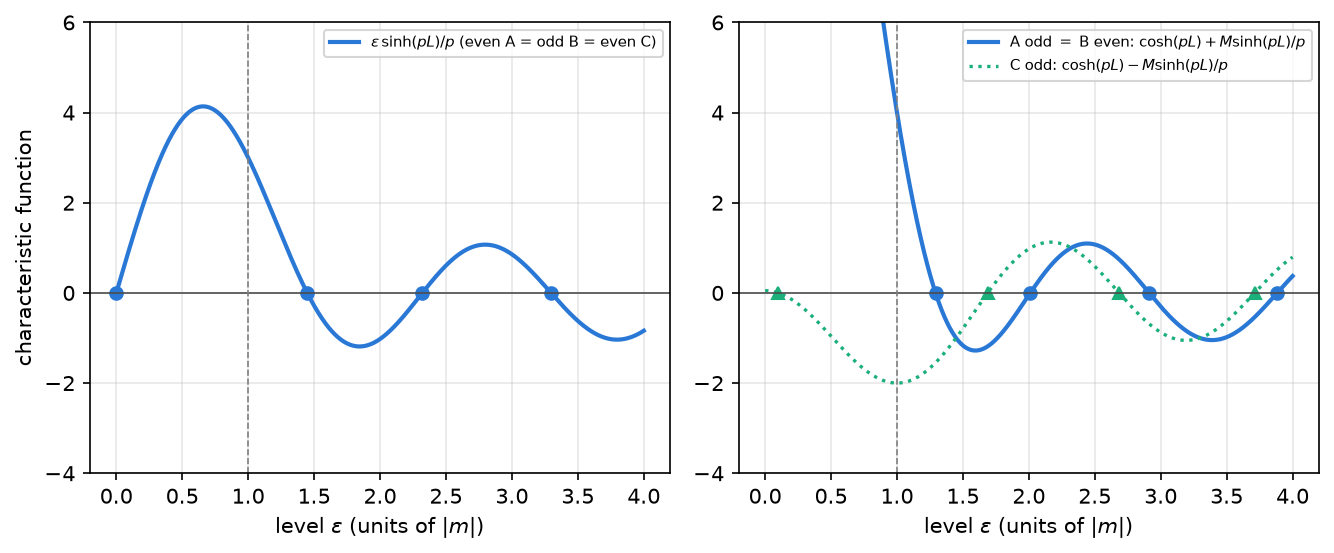

Figure 19b.4 saved as Revision/textbook/figures/19b_4_characteristic_functions.png


In [14]:
eps_b = levels["C odd"][0]  # the first zero: inside the gap?
q_b = math.sqrt(M_BARE ** 2 - eps_b ** 2)
two_forms = (abs(math.tanh(q_b * L_TIP) - q_b / M_BARE) < 1e-12
             and abs(M_BARE / math.cosh(q_b * L_TIP) - eps_b) < 1e-12)
report("sub-gap level of the control eps_b", f"{eps_b:.12f}", "|m|")
above = levels["C odd"][1:]  # the control's odd levels above the gap
distinct = min(abs(x - y) for x in above for y in levels["A odd"]) > 1e-3
check(0.0 < eps_b < M_BARE and two_forms and distinct,
      "only the control has a level in the gap, eps_b = M/cosh(qL), tanh(qL) = q/M")

grid = np.linspace(0.0, 4.0, 2001)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
left.plot(grid, f_A_even(grid), color="#2a78d6", lw=2.0,
          label="$\\varepsilon\\,\\sinh(pL)/p$ (even A = odd B = even C)")
left.plot(levels["A even"], np.zeros(len(levels["A even"])), "o", color="#2a78d6")
right.plot(grid, f_A_odd(grid), color="#2a78d6", lw=2.0,
           label="A odd $= $ B even: $\\cosh(pL) + M\\sinh(pL)/p$")
right.plot(grid, f_C_odd(grid), color="#1baf7a", lw=1.6, ls=":",
           label="C odd: $\\cosh(pL) - M\\sinh(pL)/p$")
right.plot(levels["A odd"], np.zeros(len(levels["A odd"])), "o", color="#2a78d6")
right.plot(levels["C odd"], np.zeros(len(levels["C odd"])), "^", color="#1baf7a")
for ax in (left, right):
    ax.axhline(0.0, color="0.3", lw=0.8)
    ax.axvline(M_BARE, color="0.5", lw=0.8, ls="--")  # the edge of the mass gap
    ax.set_xlabel("level $\\varepsilon$ (units of $|m|$)")
    ax.set_ylim(-4.0, 6.0)
    ax.legend(fontsize=7, loc="upper right")
left.set_ylabel("characteristic function")
fig.tight_layout()
save_figure(fig, "characteristic_functions",
            "The characteristic functions of the zero-momentum spectra for "
            "$M = 1$, $L = 3$ (horizontal axis: the level $\\varepsilon$ in units "
            "of $|m|$; the dashed vertical line is the edge $\\varepsilon = M$ of "
            "the mass gap). Left: the function of the even sector of A, which is "
            "also that of the odd sector of the partner B and of the even sector of "
            "the control C; its zeros (dots) are $0$ and $\\sqrt{M^2 + "
            "(n\\pi/L)^2}$. Right: the odd sector of A (equal to the even sector of "
            "B) and the odd sector of the control C. Only C has a zero inside the "
            "gap, the level $\\varepsilon_b = 0.1009$, and its other zeros differ "
            "from those of A.")

## 9. The same levels without formulas: shooting at zero momentum

The levels of section 8 came from formulas. The next cells find them again by
**shooting**, which needs no formula and works for every $k$ and every potential.
The real equations of section 4 are integrated from the tip, where the tip
condition fixes the start ($(a, b) = (1, 0)$ for $\theta = 0$, that is
$\chi_2(-L) = 0$; $(a, b) = (0, 1)$ for $\theta = \pi$), to the brane with the
classical Runge-Kutta method (RK4, 3000 steps of length $0.001$). A level is a value
of $\varepsilon$ for which the brane condition holds: $b(0) = 0$ (even) or
$a(0) = 0$ (odd). The function `brane_value` returns the component that must vanish;
it works on whole numpy arrays of problems at once (every array entry is one
problem: its level, momentum, mass, block type, tip angle and parity). The function
`find_levels` scans $\varepsilon$ on a grid, keeps every sign change, and refines
each one with the **Illinois method** (a safeguarded secant rule: keep a bracket with
a sign change, take the zero of the straight line through its ends as the new
point, keep the part with the sign change, and halve the stored value at an end that
is kept twice in a row, so that both ends move).

In [15]:
H, STEPS = 1.0, 3000  # the constant H and the number of RK4 steps


def brane_value(e, kk, mass, j, tip, odd):
    """Shoot from the tip y = -L to the brane y = 0 at the slice a4,0 = 0.  All
    arguments are numpy arrays of equal shape (one entry per problem); returns
    a(0) where odd is 1 and b(0) where odd is 0."""
    a = np.where(tip == 0.0, 1.0, 0.0)  # theta = 0: (a, b) = (1, 0) at the tip
    b = 1.0 - a  # theta = pi: (a, b) = (0, 1)
    step = L_TIP / STEPS

    def slope(yv, a, b):
        w = math.exp(-H * yv) * kk  # kappa(y) k
        return mass * a - (w + j * e) * b, (j * e - w) * a - mass * b

    for i in range(STEPS):
        yv = -L_TIP + i * step
        ka1, kb1 = slope(yv, a, b)
        ka2, kb2 = slope(yv + step / 2, a + step / 2 * ka1, b + step / 2 * kb1)
        ka3, kb3 = slope(yv + step / 2, a + step / 2 * ka2, b + step / 2 * kb2)
        ka4, kb4 = slope(yv + step, a + step * ka3, b + step * kb3)
        a = a + step / 6 * (ka1 + 2 * ka2 + 2 * ka3 + ka4)
        b = b + step / 6 * (kb1 + 2 * kb2 + 2 * kb3 + kb4)
    return np.where(odd == 1.0, a, b)


def find_levels(problems, top, points=2001, rounds=16, first_only=False):
    """problems: rows (k, mass, j, tip, odd).  Returns (row index, level) for every
    sign change of brane_value on (0, top] (only the lowest one per row when
    first_only is True)."""
    P = np.array(problems, dtype=float)
    grid = np.linspace(1e-9, top, points)
    columns = [np.repeat(P[:, c:c + 1], points, axis=1) for c in range(5)]
    values = brane_value(np.tile(grid, (len(P), 1)), *columns)
    rows, cols = np.nonzero(np.sign(values[:, :-1]) * np.sign(values[:, 1:]) < 0)
    if first_only:  # keep the first sign change of every row
        keep = np.concatenate(([True], rows[1:] != rows[:-1]))
        rows, cols = rows[keep], cols[keep]
    lo, hi = grid[cols], grid[cols + 1]  # brackets with a sign change
    f_lo, f_hi = values[rows, cols], values[rows, cols + 1]
    data = [P[rows, c] for c in range(5)]  # the problem of every root
    kept = np.zeros(len(rows))  # which end was kept last: +1 high, -1 low
    new = lo
    for _ in range(rounds):
        new = (lo * f_hi - hi * f_lo) / (f_hi - f_lo)  # zero of the straight line
        f_new = brane_value(new, *data)
        move_low = np.sign(f_new) == np.sign(f_lo)  # the zero lies above new
        f_hi = np.where(move_low & (kept == 1), f_hi / 2, f_hi)  # Illinois rule
        f_lo = np.where(~move_low & (kept == -1), f_lo / 2, f_lo)
        lo, f_lo = np.where(move_low, new, lo), np.where(move_low, f_new, f_lo)
        hi, f_hi = np.where(move_low, hi, new), np.where(move_low, f_hi, f_new)
        kept = np.where(move_low, 1, -1)
    return rows, new


say("brane_value and find_levels defined")

brane_value and find_levels defined


The next cell solves the six sectors at $k = 0$: for A (mass $+1$, $j = +1$, tip
angle $0$) and the control C (mass $-1$, $j = +1$, tip angle $0$) the even and the
odd parity, for B (mass $-1$, $j = -1$, tip angle $\pi$) the even and the odd parity
of the partner block. It compares every level with section 8: A's sectors with the
formulas of A, B's even sector with A's odd one and B's odd sector with A's even one
(T3 exchanges the parities), C's even sector with A's even one and C's odd sector
with the control's own formula. It also checks the zero modes: the brane value is
exactly $0$ at $\varepsilon = 0$ in A even, B odd and C even.

In [16]:
SECTORS = {  # name: (mass, j, tip angle, odd)
    "A even": (1.0, 1.0, 0.0, 0.0), "A odd": (1.0, 1.0, 0.0, 1.0),
    "B even": (-1.0, -1.0, math.pi, 0.0), "B odd": (-1.0, -1.0, math.pi, 1.0),
    "C even": (-1.0, 1.0, 0.0, 0.0), "C odd": (-1.0, 1.0, 0.0, 1.0)}
names_k0 = list(SECTORS)
rows, found = find_levels([(0.0, *SECTORS[name]) for name in names_k0], top=4.0)
shot = {name: sorted(found[rows == r]) for r, name in enumerate(names_k0)}
zero_mode = {name: float(brane_value(np.zeros(1), np.zeros(1),
                                     *(np.full(1, x) for x in SECTORS[name]))[0])
             for name in ("A even", "B odd", "C even")}
for name in ("A even", "B odd", "C even"):
    shot[name] = [0.0] + shot[name]  # the zero mode at eps = 0
expected = {"A even": levels["A even"], "A odd": levels["A odd"],
            "B even": levels["A odd"], "B odd": levels["A even"],
            "C even": levels["A even"], "C odd": levels["C odd"]}
worst_shot = 0.0
for name in names_k0:
    say(f"{name}: " + ", ".join(f"{e:.10f}" for e in shot[name]))
    if len(shot[name]) != len(expected[name]):
        worst_shot = math.inf  # a level is missing or extra
    else:
        worst_shot = max(worst_shot, max(abs(x - y) for x, y in
                                         zip(shot[name], expected[name])))
report("largest difference shooting - formula at k = 0", f"{worst_shot:.1e}")
check(worst_shot < 1e-9 and all(v == 0.0 for v in zero_mode.values()),
      "shooting finds exactly the formula levels of A, B and C at k = 0")

A even: 0.0000000000, 1.4479719304, 2.3208814802, 3.2969083095
A odd: 1.2922928281, 2.0106285600, 2.9119358754, 3.8829900326
B even: 1.2922928281, 2.0106285600, 2.9119358754, 3.8829900326
B odd: 0.0000000000, 1.4479719304, 2.3208814802, 3.2969083095
C even: 0.0000000000, 1.4479719304, 2.3208814802, 3.2969083095
C odd: 0.1008511214, 1.6875789860, 2.6839784554, 3.7115109122
RESULT largest difference shooting - formula at k = 0 = 5.9e-12
PASS shooting finds exactly the formula levels of A, B and C at k = 0


The next cell draws the three ladders found by shooting (both signs: at $k = 0$ the
levels come in pairs $\pm\varepsilon$, because the functions of section 8 are even
or odd in $\varepsilon$) and checks that the ladders of A and B agree level by level
to $10^{-12}$, although the two were computed with different masses, block types,
tip conditions and parities.

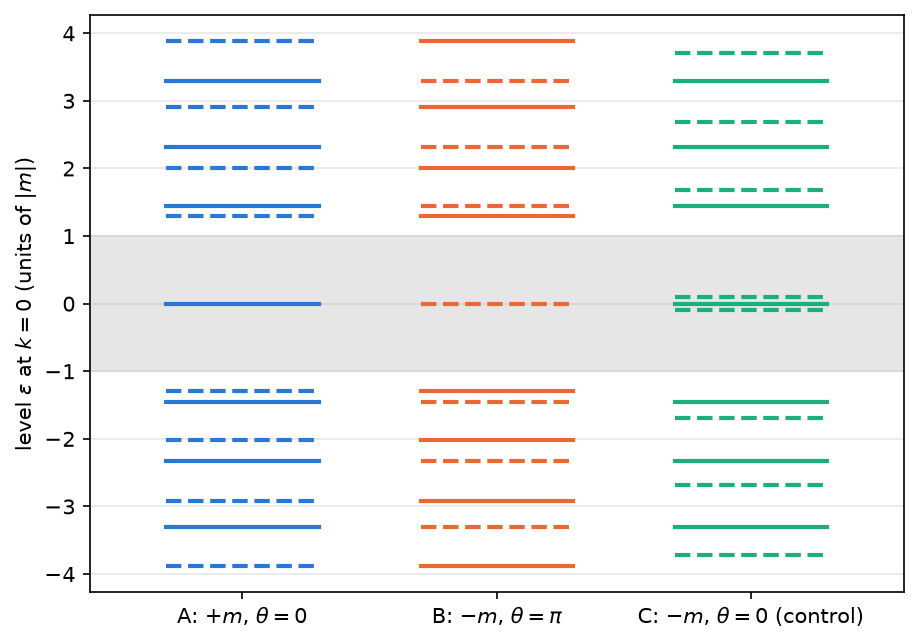

Figure 19b.5 saved as Revision/textbook/figures/19b_5_k0_ladders.png
PASS the shooting ladders of A and B agree level by level


In [17]:
COLOUR = {"A": "#2a78d6", "B": "#eb6834", "C": "#1baf7a"}
fig, ax = plt.subplots(figsize=(7.0, 5.0))
for x, kind in enumerate("ABC"):
    for parity, style in (("even", "-"), ("odd", "--")):
        for e in shot[f"{kind} {parity}"]:
            for sign in ((1,) if e == 0.0 else (1, -1)):
                ax.plot([x - 0.3, x + 0.3], [sign * e, sign * e],
                        color=COLOUR[kind], ls=style, lw=2.0)
ax.axhspan(-M_BARE, M_BARE, color="0.9", zorder=0)  # the mass gap
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["A: $+m$, $\\theta = 0$", "B: $-m$, $\\theta = \\pi$",
                    "C: $-m$, $\\theta = 0$ (control)"])
ax.set_xlim(-0.6, 2.6)
ax.set_ylabel("level $\\varepsilon$ at $k = 0$ (units of $|m|$)")
ax.grid(axis="x", visible=False)
save_figure(fig, "k0_ladders",
            "The levels at zero momentum of the universes A (mass $+m$, tip angle "
            "0), B (mass $-m$, tip angle $\\pi$, the T3 partner) and C (mass $-m$, "
            "tip angle 0, the control), for $m = 1$, $L = 3$, no interaction, found "
            "by shooting (vertical axis: the level in units of $|m|$; solid lines "
            "even parity, dashed lines odd parity; grey band: the mass gap "
            "$|\\varepsilon| < m$). A and B have the same ladder with the parities "
            "exchanged; the control has different odd levels and the pair "
            "$\\pm\\varepsilon_b$ inside the gap.")
ladder_A = np.array(sorted(shot["A even"] + shot["A odd"]))
ladder_B = np.array(sorted(shot["B even"] + shot["B odd"]))
check(len(ladder_A) == len(ladder_B)
      and float(np.max(np.abs(ladder_A - ladder_B))) < 1e-12,
      "the shooting ladders of A and B agree level by level")

## 10. Small momenta: the brane band

At small $k$ the zero mode of A turns into the **brane band**, a level that grows
linearly with $k$. Its slope follows from first-order perturbation theory (the
Hellmann-Feynman rule: a small change $\delta h$ of $h$ moves a level by
$\langle\chi|\delta h|\chi\rangle/\langle\chi|\chi\rangle$, where
$\langle\chi|X|\chi\rangle = \int_{-L}^{0}\chi^\dagger X\chi\,dy$). Here
$\delta h = jk\kappa\sigma_3$ with $\kappa = e^{-Hy}$ at $a_{4,0} = 0$. For A,
$j = 1$ and $\chi = (e^{My}, 0)$, so $\chi^\dagger\sigma_3\chi = e^{2My}$ and

$$c = \frac{\int_{-L}^0 e^{(2M - H)y}dy}{\int_{-L}^0 e^{2My}dy} =
\frac{2M}{2M - H}\,\frac{1 - e^{-(2M - H)L}}{1 - e^{-2ML}} .$$

For B, $j = -1$ and $\chi = (0, ie^{My})$, so $j\chi^\dagger\sigma_3\chi =
(-1)(-e^{2My})$: the same slope. For the control C, $j = 1$ and $\chi =
(e^{-My}, 0)$, living at the tip where $\kappa$ is large:

$$c_{ctrl} = \frac{\int_{-L}^0 e^{-(2M + H)y}dy}{\int_{-L}^0 e^{-2My}dy} =
\frac{2M}{2M + H}\,\frac{e^{(2M + H)L} - 1}{e^{2ML} - 1} .$$

The next cell finds, by shooting, the lowest positive level of the band sector (A:
$j = +1$, even; B: $j = -1$, odd; C: $j = +1$, even) at 25 momenta between $0.01$
and $0.25$, for the three universes in one computation.

In [18]:
BAND = {"A": (1.0, 1.0, 0.0, 0.0), "B": (-1.0, -1.0, math.pi, 1.0),
        "C": (-1.0, 1.0, 0.0, 0.0)}  # mass, j, tip angle, odd
k_plot = np.linspace(0.0, 0.25, 26)[1:]  # 25 momenta for the figure
problems = [(kk, *BAND[kind]) for kind in "ABC" for kk in k_plot]
rows, found = find_levels(problems, top=2.0, points=401, first_only=True)
band = {kind: found[i * len(k_plot):(i + 1) * len(k_plot)]
        for i, kind in enumerate("ABC")}
band_gap = float(np.max(np.abs(band["A"] - band["B"])))
report("largest |eps_A - eps_B| on the band", f"{band_gap:.1e}")
check(len(rows) == 3 * len(k_plot) and band_gap < 1e-10
      and float(np.min(np.abs(band["A"] - band["C"]))) > 1e-3,
      "the band of B equals that of A at every momentum; the control differs")

RESULT largest |eps_A - eps_B| on the band = 0.0e+00
PASS the band of B equals that of A at every momentum; the control differs


The next cell measures the slopes at $k \to 0$. The band is an odd function of $k$,
$\varepsilon(k) = ck + dk^3 + \dots$, so with $\varepsilon(k)/k = c + dk^2$ at $k$
and $2k$ the combination $[4\varepsilon(k)/k - \varepsilon(2k)/(2k)]/3$ removes the
$k^2$ term (Richardson extrapolation). It uses $k = 10^{-4}$ and $2 \times 10^{-4}$
and compares with the closed forms and with the slope stored in the records
(`ks-theory.json`, key `checksNumeric`, and
`Revision/kohn_sham/results/spectrum/brane-band-slope.csv`).

In [19]:
small = 1e-4
problems = [(kk, *BAND[kind]) for kind in "ABC" for kk in (small, 2 * small)]
rows, found = find_levels(problems, top=0.01, points=401, first_only=True)
slopes = {kind: (4 * found[2 * i] / small - found[2 * i + 1] / (2 * small)) / 3
          for i, kind in enumerate("ABC")}
c_A = (2 * M_BARE / (2 * M_BARE - H) * (1 - math.exp(-(2 * M_BARE - H) * L_TIP))
       / (1 - math.exp(-2 * M_BARE * L_TIP)))
c_C = (2 * M_BARE / (2 * M_BARE + H) * (math.exp((2 * M_BARE + H) * L_TIP) - 1)
       / (math.exp(2 * M_BARE * L_TIP) - 1))
c_record = float(ks["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])
SLOPES = "Revision/kohn_sham/results/spectrum/brane-band-slope.csv"
with repository_file(SLOPES).open(encoding="utf-8", newline="") as handle:
    c_csv = float(next(csv.DictReader(handle))["c_theory"])  # the row a4,0 = 0
say(f"closed forms: c = {c_A:.13f}, c_ctrl = {c_C:.10f}; records: "
    f"{c_record:.13f} and {c_csv:.13f}")
for kind in "ABC":
    say(f"{kind}: shooting slope {slopes[kind]:.10f}")
check(len(rows) == 6 and abs(c_A - c_record) < 1e-13 and abs(c_A - c_csv) < 1e-13
      and abs(slopes["A"] / c_A - 1) < 1e-7 and abs(slopes["B"] / c_A - 1) < 1e-7,
      "the brane-band slope of A and of its partner B is c = 1.9051482536",
      record=f"{KS_THEORY}, checksNumeric braneBandSlope_M1_H1_L3_a0, and {SLOPES}")
check(abs(slopes["C"] / c_C - 1) < 1e-6 and c_C > 7 * c_A,
      "the control's band starts with the much larger slope c_ctrl = 13.42")

closed forms: c = 1.9051482536449, c_ctrl = 13.4219751976; records: 1.9051482536449 and
    1.9051482536449
A: shooting slope 1.9051482536
B: shooting slope 1.9051482536
C: shooting slope 13.4219751976
PASS the brane-band slope of A and of its partner B is c = 1.9051482536
     reproduces Revision/kohn_sham/ks-theory.json, checksNumeric
    braneBandSlope_M1_H1_L3_a0, and Revision/kohn_sham/results/spectrum/brane-band-
    slope.csv
PASS the control's band starts with the much larger slope c_ctrl = 13.42


The next cell draws the lowest positive level of the band sector against the
momentum for the three universes, with the straight lines $ck$ and $c_{ctrl}k$.

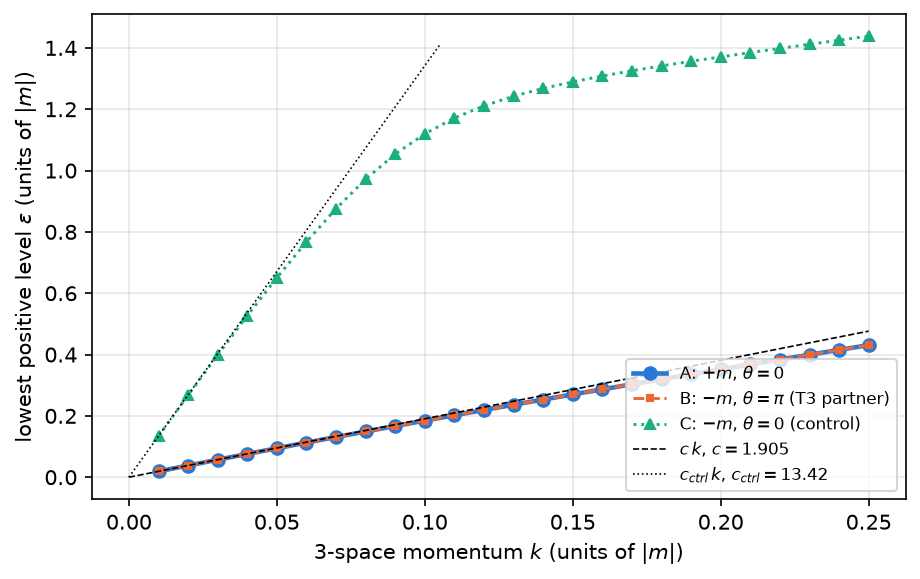

Figure 19b.6 saved as Revision/textbook/figures/19b_6_brane_band.png


In [20]:
fig, ax = plt.subplots()
ax.plot(k_plot, band["A"], "o-", color=COLOUR["A"], lw=2.2, ms=6,
        label="A: $+m$, $\\theta = 0$")
ax.plot(k_plot, band["B"], "s--", color=COLOUR["B"], lw=1.4, ms=3,
        label="B: $-m$, $\\theta = \\pi$ (T3 partner)")
ax.plot(k_plot, band["C"], "^:", color=COLOUR["C"], lw=1.4, ms=5,
        label="C: $-m$, $\\theta = 0$ (control)")
k_line = np.linspace(0.0, 0.25, 51)
ax.plot(k_line, c_A * k_line, "k--", lw=0.8, label="$c\\,k$, $c = 1.905$")
short = k_line[k_line < 0.11]  # the control's line leaves the picture early
ax.plot(short, c_C * short, "k:", lw=0.8, label="$c_{ctrl}\\,k$, $c_{ctrl} = 13.42$")
ax.set_xlabel("3-space momentum $k$ (units of $|m|$)")
ax.set_ylabel("lowest positive level $\\varepsilon$ (units of $|m|$)")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "brane_band",
            "The lowest positive level of the band sector against the 3-space "
            "momentum $k$ (both in units of $|m|$) at the slice $a_{4,0} = 0$, for "
            "$m = 1$, $L = 3$, no interaction, found by shooting: A (blue circles), "
            "its T3 partner B (orange squares, on top of A) and the control C (aqua "
            "triangles). A and B start with the slope $c = 1.905$ of the brane band "
            "(dashed); the control's zero mode lives at the tip, where the redshift "
            "factor $e^{-Hy}$ is largest, so its level rises with the slope "
            "$c_{ctrl} = 13.42$ (dotted) and soon bends below the first level of "
            "the bulk.")

## 11. The last check

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [21]:
paths = [output_file(f"{FIGURE_FOLDER}/{name}.png") for name in
         ["19b_1_eight_gammas", "19b_2_gamma_block_map", "19b_3_mean_field_map",
          "19b_4_characteristic_functions", "19b_5_k0_ladders", "19b_6_brane_band"]]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 19 CHECKS PASSED (notebook 19b)


## 12. What this notebook showed

- PROVED in the records and re-checked here exactly (integers and sympy): the
  author's eight gamma matrices are real $16 \times 16$ signed permutation matrices
  with $\gamma^a\gamma^b + \gamma^b\gamma^a = 2\eta^{ab}\mathbf{1}$; the chirality
  $\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$ is
  $\mathrm{diag}(-1, \dots, -1, +1, \dots, +1)$ and maps each Kohn-Sham block
  $(j, s_2, s_3)$ onto $(-j, s_2, s_3)$ as $s_2\sigma_2$.
- PROVED (sympy, reproducing the checks of `python-t3.json`): the four steps of T3:
  $\sigma_2h_j(M)\sigma_2 = h_{-j}(-M)$; the tip angle goes to $\pi - \theta$ and the
  brane parities are exchanged; $n$, $t$ keep and $S$, $Q$ change their sign; the
  mean field closes exactly for $(-m, +\lambda)$ and not for $(-m, -\lambda)$.
- PROVED (sympy) and COMPUTED (roots): at zero momentum A and B have the same
  levels; the control C, with the untransformed tip, has different odd levels and a
  level inside the mass gap, $\varepsilon_b = m/\cosh(qL)$ with $\tanh(qL) = q/m$.
- COMPUTED (shooting) against closed forms: the brane band of A and B starts with the
  slope $c = 1.9051482536$ of the record; the control's band with
  $c_{ctrl} = 13.42$, because its zero mode lives at the tip.
- ASSUMED: the $Z_2$ brane; the tip condition is a choice (T3 needs the transformed
  tip angle); instantaneous mean-field states on a PRESCRIBED BACKGROUND history.
- NOT shown: that a universe is created, in pairs or otherwise. T3 maps solutions
  onto solutions; it gives no creation process, rate or amplitude.